In [2]:
from warnings import filterwarnings

# for datasets
import mudatasets
import muon as mu
import pandas as pd
import scanpy as sc

filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\muon\_core\preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
sc.set_figure_params(fontsize=18, figsize=[6, 6])

In [4]:
adata = sc.datasets.pbmc3k_processed()
adata = adata.raw.to_adata()  # Store raw counts in adata.X

In [5]:
def print_size_in_MB(x):
    print(f"{x.__sizeof__() / 1e6:.3} MB")
print_size_in_MB(adata)

21.2 MB


In [6]:
print_size_in_MB(adata)

21.2 MB


In [7]:
adata.write_h5ad("./data/pbmc3k_processed_raw.h5ad")
adata = sc.read_h5ad("./data/pbmc3k_processed_raw.h5ad", backed = True)

In [8]:
print_size_in_MB(adata)

3.28 MB


In [9]:
adata.isbacked

True

In [10]:
adata.filename

WindowsPath('data/pbmc3k_processed_raw.h5ad')

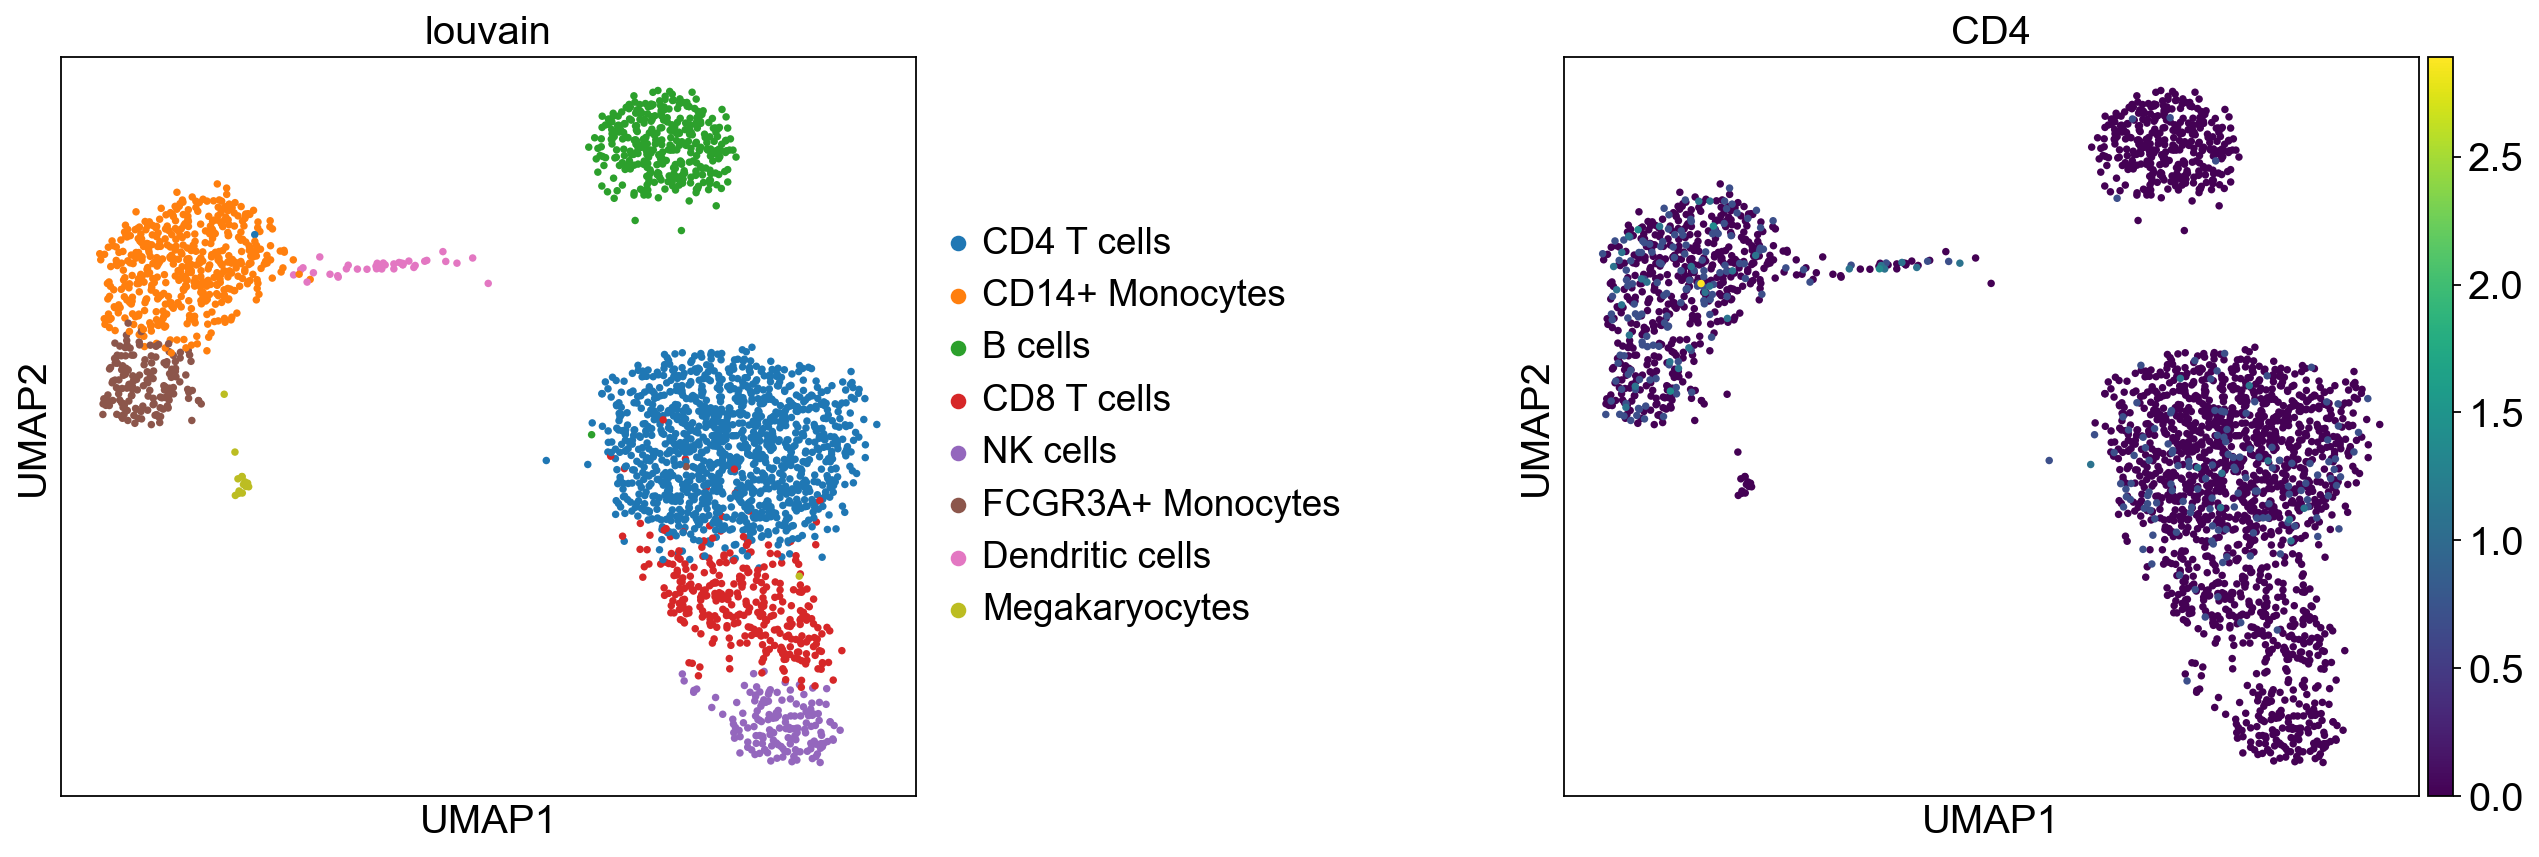

In [11]:
sc.pl.umap(adata, color=["louvain", "CD4"], wspace=0.6)

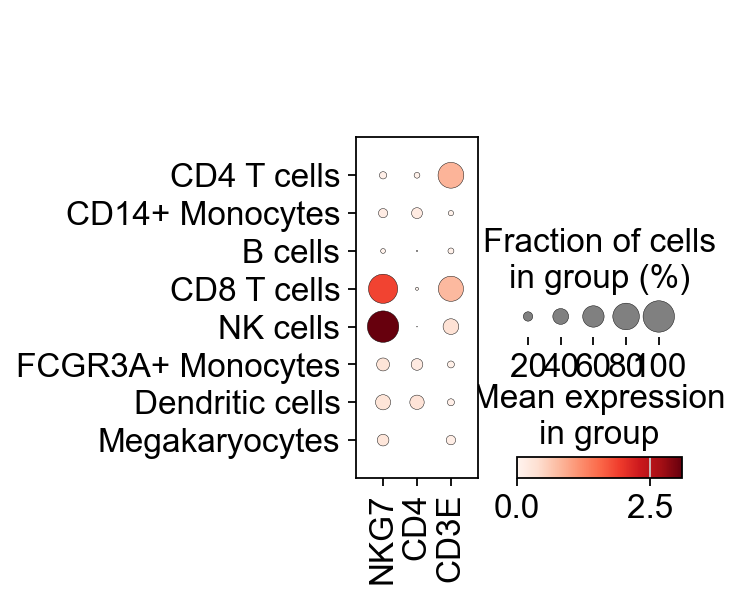

In [12]:
sc.pl.dotplot(adata, var_names=["NKG7", "CD4", "CD3E"], groupby="louvain")

In [13]:
sc.pp.neighbors(adata, n_neighbors=20)
sc.tl.umap(adata)

In [14]:
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_res0.5")

In [15]:
adata.obs

,n_genes,percent_mito,n_counts,louvain,leiden_res0.5
index,,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells,0
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells,3
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,0
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,1
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,2
...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459.0,CD14+ Monocytes,1
TTTCTACTGAGGCA-1,1227,0.009294,3443.0,B cells,3
TTTCTACTTCCTCG-1,622,0.021971,1684.0,B cells,3


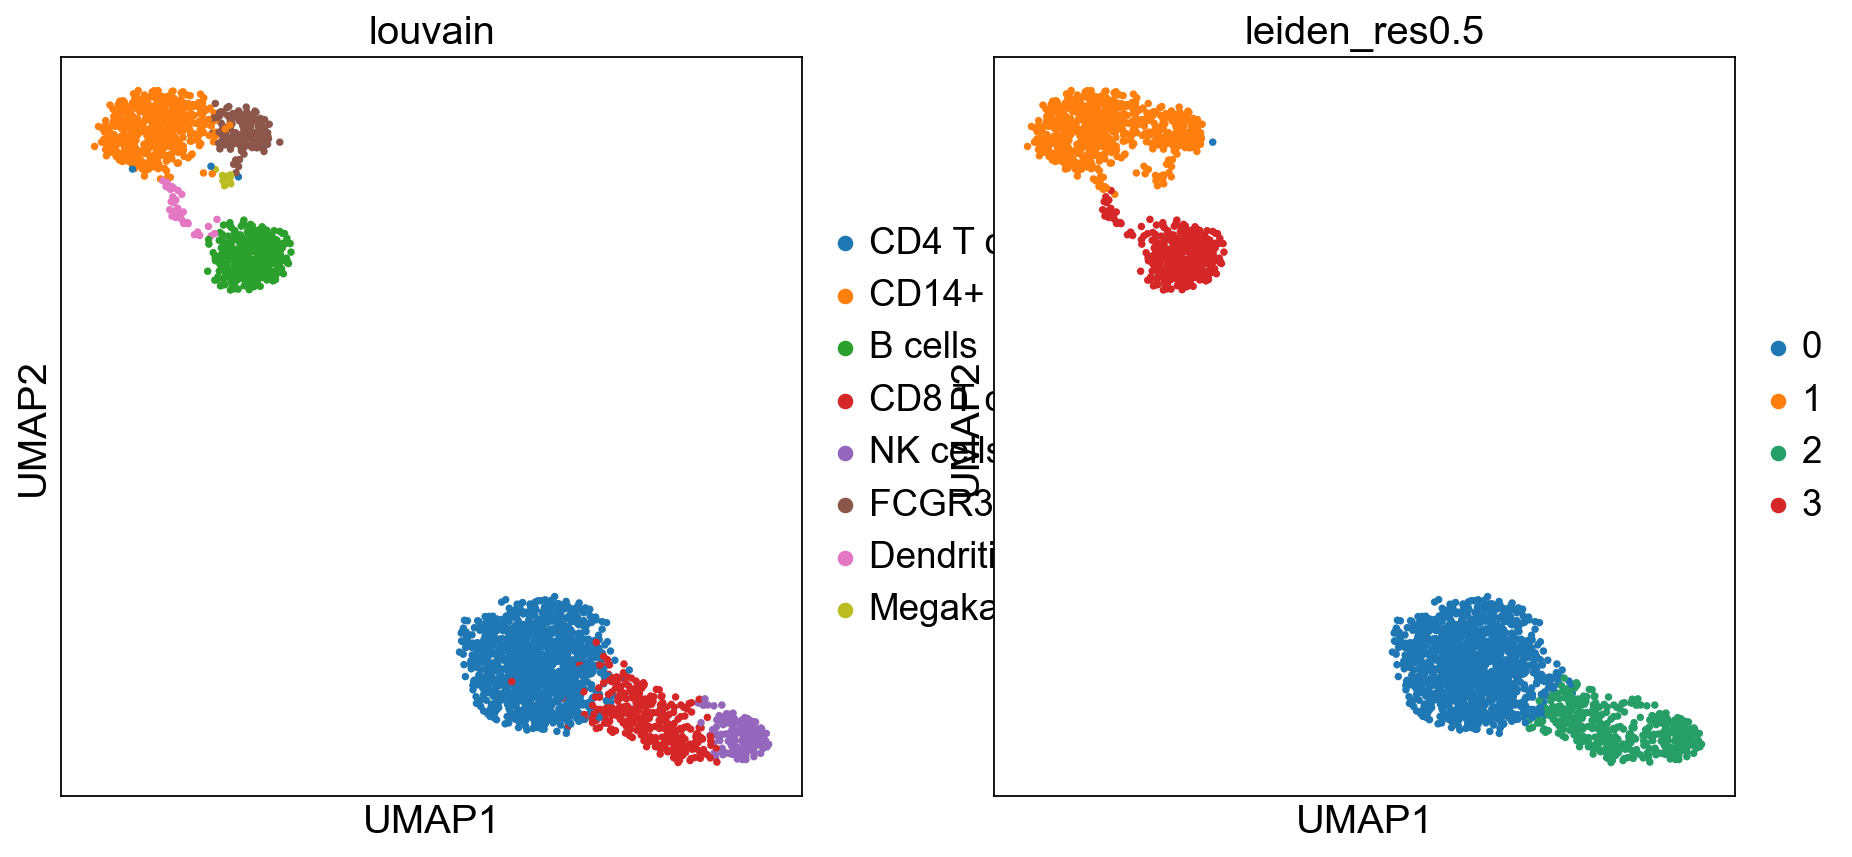

In [16]:
sc.pl.umap(adata, color=["louvain", "leiden_res0.5"])

In [17]:
T_clusters = ["CD4 T cells", "CD8 T cells"]
adata_subset = adata[adata.obs["louvain"].isin(T_clusters)].to_memory()

In [18]:
adata_subset

AnnData object with n_obs × n_vars = 1460 × 13714
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'leiden_res0.5'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'leiden_res0.5', 'leiden_res0.5_colors'
    obsm: 'X_draw_graph_fr', 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [19]:
adata_subset.isbacked

False

In [20]:
adata_subset = adata[adata.obs["louvain"].isin(T_clusters)].copy(filename="./data/pbmc3k_processed_CD4Tcells.h5ad")

In [21]:
adata_subset

AnnData object with n_obs × n_vars = 1460 × 13714 backed at 'data\\pbmc3k_processed_CD4Tcells.h5ad'
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'leiden_res0.5'
    var: 'n_cells'
    uns: 'draw_graph', 'leiden_res0.5', 'leiden_res0.5_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_draw_graph_fr', 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [22]:
adata_subset.isbacked

True

In [23]:
# Download mudata object and save in h5mu format
mdata = mudatasets.load("pbmc10k_multiome")
mdata["rna"].var_names_make_unique()
mdata.write_h5mu("./data/pbmc10k_multiome.h5mu")

■ File filtered_feature_bc_matrix.h5 from pbmc10k_multiome has been found at C:\Users\Davi/mudatasets/pbmc10k_multiome\filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\mudatasets\core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
  warn("Dataset is in the 10X .h5 format and can't be loaded as backed.")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from C:\Users\Davi/mudatasets/pbmc10k_multiome\filtered_feature_bc_matrix.h5


c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\mudata\_core\mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)


In [24]:
mdata["atac"].isbacked

False

In [25]:
print_size_in_MB(mdata["atac"])

7.16e+02 MB


In [26]:
mdata = mu.read_h5mu("./data/pbmc10k_multiome.h5mu", backed=True)

In [27]:
mdata

MuData object with n_obs × n_vars = 11909 × 144978 backed at 'data\\pbmc10k_multiome.h5mu'
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11909 x 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	11909 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [28]:
print_size_in_MB(mdata["atac"])

31.6 MB


In [29]:
mdata.mod["rna"] = mdata.mod["rna"].to_memory()

In [30]:
mdata["rna"].isbacked

False

In [31]:
mdata["atac"].isbacked

True

In [32]:
from pandas._libs.tslibs import Resolution
rna = mdata.mod["rna"]

sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

sc.tl.pca(rna, svd_solver="arpack")
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)
sc.tl.umap(rna)
sc.tl.leiden(rna, resolution=1.0)

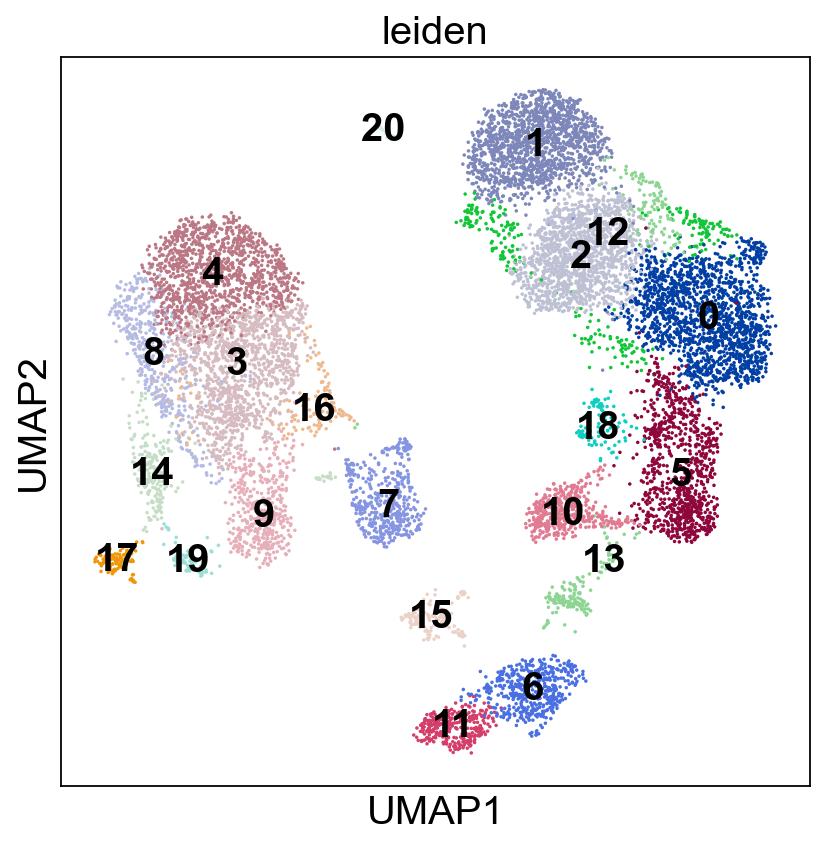

In [33]:
sc.pl.umap(rna, color="leiden", legend_loc="on data")

In [34]:
mdata["rna"]


AnnData object with n_obs × n_vars = 11909 × 36601
    obs: 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [35]:
mdata["rna"].layers["lognorm_counts"] = mdata["rna"].X.copy()

mdata.write_h5mu()

In [36]:
mdata = mu.read_h5mu("./data/pbmc10k_multiome.h5mu", backed=True)

In [37]:
mdata

MuData object with n_obs × n_vars = 11909 × 144978 backed at 'data\\pbmc10k_multiome.h5mu'
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11909 x 36601
      obs:	'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'lognorm_counts'
      obsp:	'connectivities', 'distances'
    atac:	11909 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [38]:
mdata["atac"].isbacked and mdata["rna"].isbacked

True

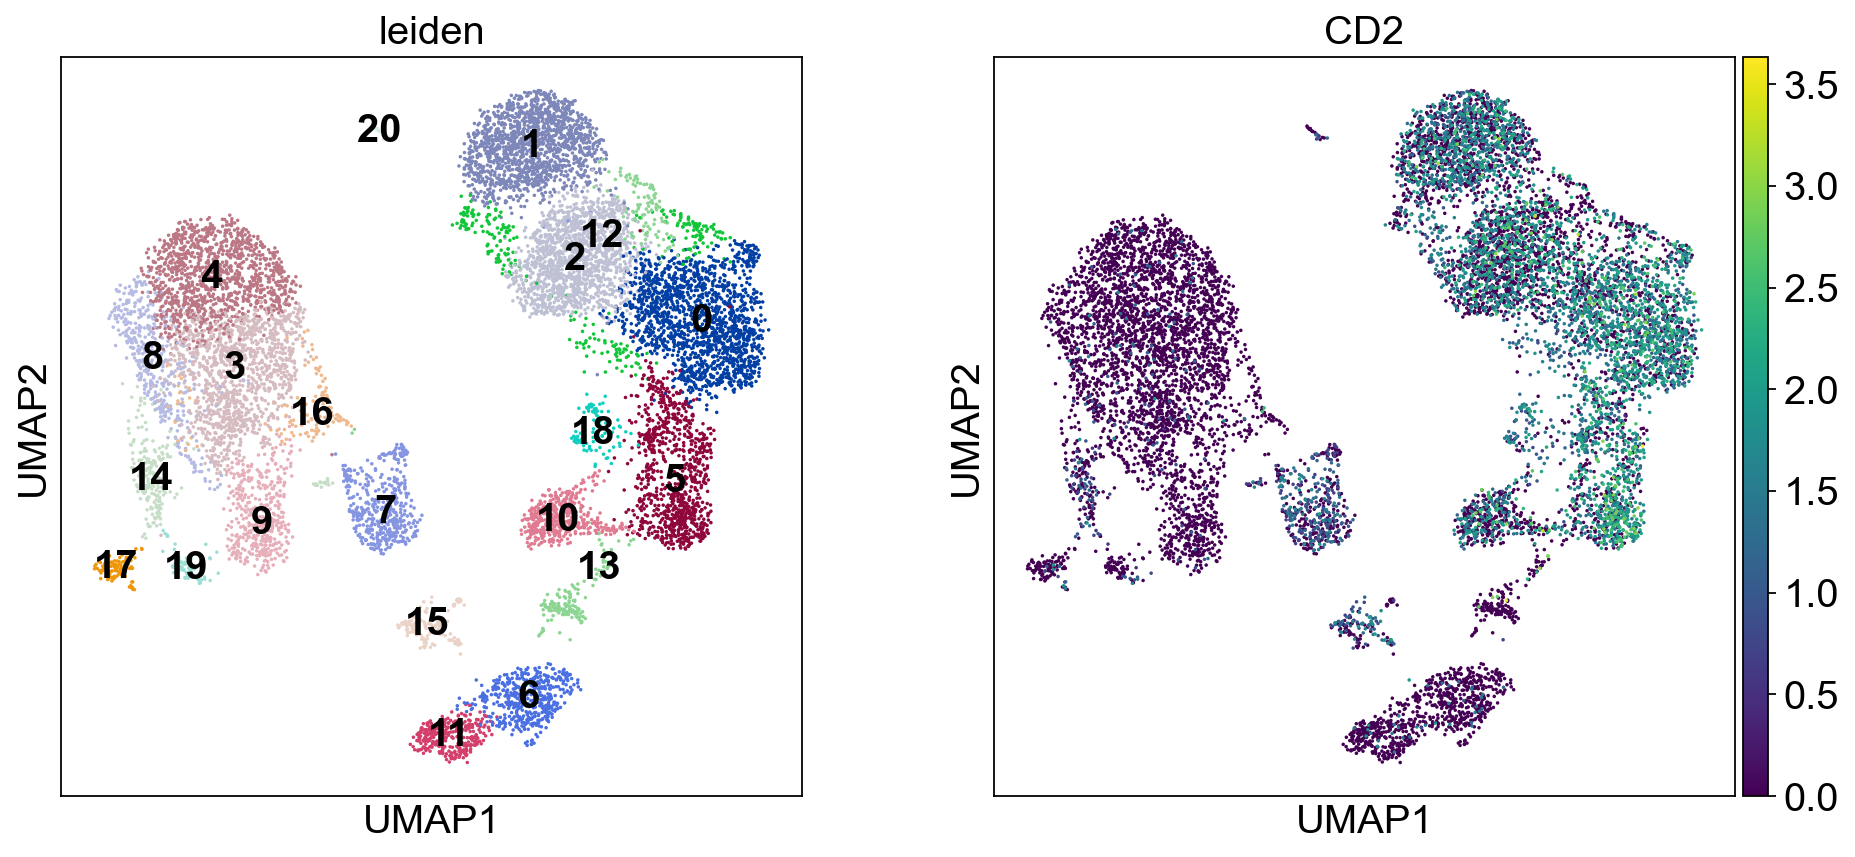

In [39]:
sc.pl.umap(mdata["rna"], color=["leiden", "CD2"], layer="lognorm_counts", legend_loc="on data")

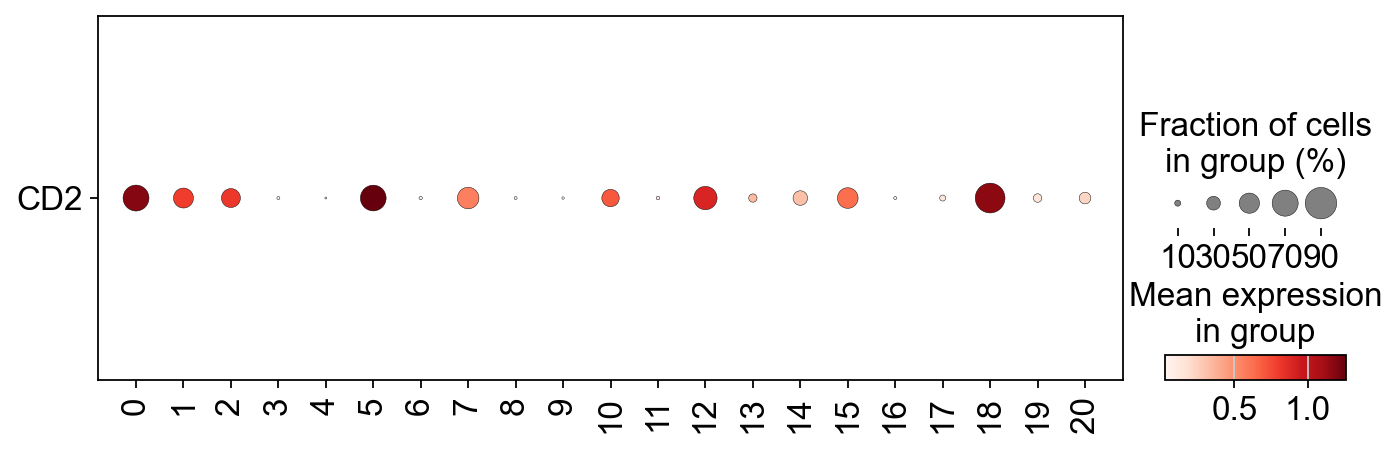

In [40]:
sc.pl.dotplot(mdata["rna"], var_names=["CD2"], groupby="leiden", figsize=(10, 3), swap_axes=True)

In [41]:
nkt_cell_clusters = ["19", "20", "13", "11", "9", "14", "19", "5", "0", "1", "3"]
mdata[mdata.obs["rna:leiden"].isin(nkt_cell_clusters)]

View of MuData object with n_obs × n_vars = 6646 × 144978 backed at 'data\\pbmc10k_multiome.h5mu'
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	6646 x 36601
      obs:	'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'lognorm_counts'
      obsp:	'connectivities', 'distances'
    atac:	6646 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'